# SSL-предобучения (100k BigP3BCI → 1D U-Net masked reconstruction)

В этом ноутбуке реализовано self-supervised предобучение модели для EEG-сигналов (P300 BCI) с использованием задачи masked reconstruction.

## Pipeline

1. Загрузка SSL-датасета (BigP3BCI)
2. Формирование subject-level train/val split
3. Time masking (~50% сигнала)
4. Обучение модели (UNet1D)
5. Сохранение encoder и логов обучения
6. Визуальная проверка реконструкций

## Input

* `ssl_bigp3bci.zarr` или `.npy` subset

## Output

* encoder checkpoints (`encoder_best.pt`)
* full model checkpoints
* loss history
* reconstruction examples

## Goal

Получить encoder, способный извлекать полезные представления ЭЭГ-сигнала без использования разметки.


## 1. Пути и импорты

In [1]:
!pip install -q zarr

In [2]:
import os, glob
print(glob.glob("/kaggle/input/*/*"))

['/kaggle/input/datasets/taisiyaglazova']


In [23]:
import json
import random
from collections import Counter
import zarr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [9]:
zarr_path = "/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-zarr/ssl_bigp3bci.zarr"

root = zarr.open(zarr_path, mode="r")
print(root["X"].shape)

(493290, 14, 208)


## 2. Проверка чтения данных и базовый sanity check

In [10]:
X = root["X"]

print("Shape:", X.shape)
print("Dtype:", X.dtype)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Shape: (493290, 14, 208)
Dtype: float32


In [15]:
idx = np.random.choice(X.shape[0], size=5, replace=False)
sample = X.get_orthogonal_selection((idx, slice(None), slice(None)))

print("Sample shape:", sample.shape)

Sample shape: (5, 14, 208)


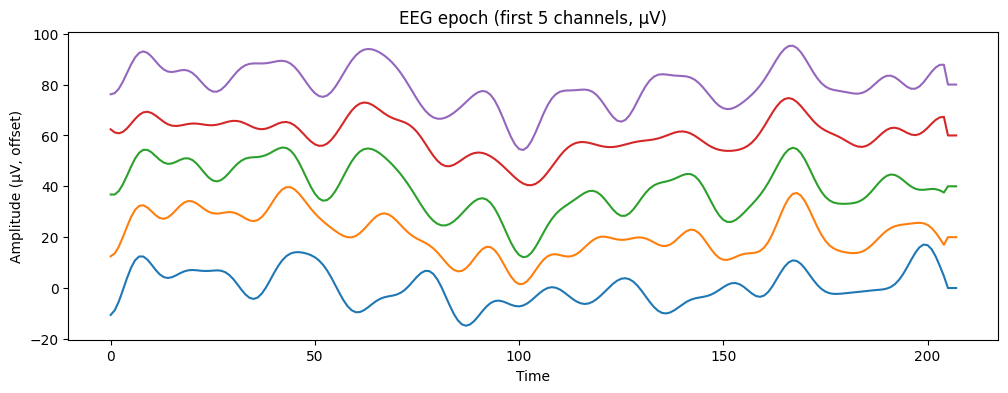

In [16]:
# визуализация

epoch = sample[0]            # (14, 208)
epoch_uv = epoch * 1e6       # перевод в µV

plt.figure(figsize=(12,4))

offset = 20  # вертикальный offset между каналами

for c in range(5):
    plt.plot(epoch_uv[c] + c*offset)

plt.title("EEG epoch (first 5 channels, µV)")
plt.xlabel("Time")
plt.ylabel("Amplitude (µV, offset)")
plt.show()

## 3. SSL subset и split по субъектам

In [28]:
subject_ids = np.asarray(root['meta']['subject_id'])
print("subject_ids shape:", subject_ids.shape)
print("example:", subject_ids[-10:])

subject_ids shape: (493290,)
example: [168 168 168 168 168 168 168 168 168 168]


In [29]:
# Полезные функции
def summarize_subject_distribution(subject_ids):
    """
    Prints basic stats for number of epochs per subject.
    """
    subject_ids = np.asarray(subject_ids)
    unique_subjects, counts = np.unique(subject_ids, return_counts=True)

    print(f"Total epochs   : {len(subject_ids):,}")
    print(f"Total subjects : {len(unique_subjects)}")
    print(f"Min epochs/subj: {counts.min():,}")
    print(f"Median         : {int(np.median(counts)):,}")
    print(f"Mean           : {counts.mean():.2f}")
    print(f"Max epochs/subj: {counts.max():,}")

    top_idx = np.argsort(counts)[::-1][:10]
    print("\nTop-10 subjects by number of epochs:")
    for i in top_idx:
        print(f"  {unique_subjects[i]} -> {counts[i]:,}")


def build_subject_to_indices(subject_ids):
    """
    Returns dict: subject_id -> np.ndarray of epoch indices
    """
    subject_ids = np.asarray(subject_ids)
    subject_to_indices = {}

    for subj in np.unique(subject_ids):
        idx = np.where(subject_ids == subj)[0]
        subject_to_indices[subj] = idx

    return subject_to_indices


def select_subject_subset(
    subject_to_indices,
    target_n_epochs=100_000,
    min_n_epochs=90_000,
    max_n_epochs=110_000,
    seed=2026,
):
    """
    Randomly shuffles subjects and keeps adding full subjects until
    total number of epochs is close to target_n_epochs.

    Strategy:
    - subjects are added whole
    - if adding the next subject gives a total closer to target than stopping now,
      we include that subject
    - final size is allowed to be around target, ideally within [min_n_epochs, max_n_epochs]
    """
    rng = np.random.default_rng(seed)

    subjects = np.array(list(subject_to_indices.keys()), dtype=object)
    rng.shuffle(subjects)

    selected_subjects = []
    total = 0

    for subj in subjects:
        n_subj = len(subject_to_indices[subj])

        if total == 0:
            selected_subjects.append(subj)
            total += n_subj
            continue

        # Если уже в допустимом диапазоне, решаем:
        # добавить следующего субъекта или остановиться
        if min_n_epochs <= total <= max_n_epochs:
            current_diff = abs(total - target_n_epochs)
            next_diff = abs((total + n_subj) - target_n_epochs)

            if next_diff < current_diff:
                selected_subjects.append(subj)
                total += n_subj
            break

        selected_subjects.append(subj)
        total += n_subj

    return selected_subjects, total


def make_subject_level_split(selected_subjects, val_ratio=0.2, seed=2026):
    """
    Splits selected subjects into train/val subject lists.
    """
    selected_subjects = np.array(selected_subjects, dtype=object)

    train_subjects, val_subjects = train_test_split(
        selected_subjects,
        test_size=val_ratio,
        random_state=seed,
        shuffle=True,
    )

    return list(train_subjects), list(val_subjects)


def subjects_to_epoch_indices(subject_to_indices, subjects):
    """
    Concatenates epoch indices for a list of subjects.
    """
    idx = [subject_to_indices[subj] for subj in subjects]
    idx = np.concatenate(idx, axis=0)
    idx = np.sort(idx)
    return idx

In [30]:
# Сводка по всему SSL-массиву
summarize_subject_distribution(subject_ids)

Total epochs   : 493,290
Total subjects : 169
Min epochs/subj: 1,350
Median         : 3,000
Mean           : 2918.88
Max epochs/subj: 10,000

Top-10 subjects by number of epochs:
  0 -> 10,000
  3 -> 9,000
  2 -> 8,508
  8 -> 8,100
  9 -> 5,400
  15 -> 5,400
  12 -> 5,400
  11 -> 4,050
  5 -> 4,050
  14 -> 4,050


In [34]:
# === CONFIG ===
SEED = 2026
TARGET_N_EPOCHS = 100_000
MIN_N_EPOCHS = 99_000
MAX_N_EPOCHS = 110_000
VAL_RATIO = 0.20

In [35]:
# Формирование subset до ~100k эпох
subject_to_indices = build_subject_to_indices(subject_ids)

selected_subjects, real_n_epochs = select_subject_subset(
    subject_to_indices=subject_to_indices,
    target_n_epochs=TARGET_N_EPOCHS,
    min_n_epochs=MIN_N_EPOCHS,
    max_n_epochs=MAX_N_EPOCHS,
    seed=SEED,
)

print(f"Selected subjects: {len(selected_subjects)}")
print(f"Real subset size : {real_n_epochs:,} epochs")
print("First 10 selected subjects:", selected_subjects[:10])

Selected subjects: 36
Real subset size : 99,564 epochs
First 10 selected subjects: [np.uint16(57), np.uint16(38), np.uint16(47), np.uint16(123), np.uint16(78), np.uint16(74), np.uint16(10), np.uint16(146), np.uint16(31), np.uint16(134)]


In [36]:
# Train / Val split по субъектам
train_subjects, val_subjects = make_subject_level_split(
    selected_subjects=selected_subjects,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

train_idx = subjects_to_epoch_indices(subject_to_indices, train_subjects)
val_idx   = subjects_to_epoch_indices(subject_to_indices, val_subjects)

print("Train subjects:", len(train_subjects))
print("Val subjects  :", len(val_subjects))
print("Train epochs  :", len(train_idx))
print("Val epochs    :", len(val_idx))
print("Total         :", len(train_idx) + len(val_idx))

Train subjects: 28
Val subjects  : 8
Train epochs  : 76642
Val epochs    : 22922
Total         : 99564


In [38]:
# Проверки, что всё корректно
# 1. Нет пересечения субъектов
assert set(train_subjects).isdisjoint(set(val_subjects)), "Train/val subjects overlap!"

# 2. Нет пересечения эпох
assert len(set(train_idx).intersection(set(val_idx))) == 0, "Train/val epoch indices overlap!"

# 3. Все выбранные эпохи покрыты
selected_idx = subjects_to_epoch_indices(subject_to_indices, selected_subjects)
assert len(selected_idx) == len(train_idx) + len(val_idx), "Mismatch in total selected indices!"

# 4. Все индексы валидны
n_epochs_total = X.shape[0]

assert train_idx.min() >= 0 and train_idx.max() < n_epochs_total
assert val_idx.min() >= 0 and val_idx.max() < n_epochs_total
print("All checks passed.")

All checks passed.


In [ ]:
# Функция для summary
def print_split_summary(subject_to_indices, train_subjects, val_subjects, train_idx, val_idx):
    print("=" * 70)
    print("SSL SUBSET SUMMARY")
    print("=" * 70)

    print(f"Train subjects: {len(train_subjects)}")
    print(f"Val subjects  : {len(val_subjects)}")
    print(f"Train epochs  : {len(train_idx):,}")
    print(f"Val epochs    : {len(val_idx):,}")
    print(f"Total epochs  : {len(train_idx) + len(val_idx):,}")

    print("\nTrain subjects:")
    for subj in train_subjects[:10]:
        print(f"  {subj} -> {len(subject_to_indices[subj]):,}")
    if len(train_subjects) > 10:
        print("  ...")

    print("\nVal subjects:")
    for subj in val_subjects[:10]:
        print(f"  {subj} -> {len(subject_to_indices[subj]):,}")
    if len(val_subjects) > 10:
        print("  ...")

    print("=" * 70)

In [40]:
# summary
print_split_summary(
    subject_to_indices=subject_to_indices,
    train_subjects=train_subjects,
    val_subjects=val_subjects,
    train_idx=train_idx,
    val_idx=val_idx,
)

SSL SUBSET SUMMARY
Train subjects: 28
Val subjects  : 8
Train epochs  : 76,642
Val epochs    : 22,922
Total epochs  : 99,564

Train subjects:
  50 -> 3,000
  149 -> 1,800
  33 -> 3,900
  123 -> 3,600
  78 -> 1,800
  134 -> 3,600
  168 -> 1,800
  89 -> 3,000
  44 -> 3,000
  9 -> 5,400
  ...

Val subjects:
  138 -> 1,800
  111 -> 3,000
  119 -> 3,600
  51 -> 3,000
  112 -> 3,000
  31 -> 3,722
  85 -> 3,000
  147 -> 1,800


In [41]:
# Сохранение split для воспроизводимости
split_info = {
    "seed": SEED,
    "target_n_epochs": TARGET_N_EPOCHS,
    "min_n_epochs": MIN_N_EPOCHS,
    "max_n_epochs": MAX_N_EPOCHS,
    "real_n_epochs": int(real_n_epochs),
    "val_ratio": VAL_RATIO,
    "n_selected_subjects": len(selected_subjects),
    "n_train_subjects": len(train_subjects),
    "n_val_subjects": len(val_subjects),
    "train_epochs": int(len(train_idx)),
    "val_epochs": int(len(val_idx)),
    "selected_subjects": [str(s) for s in selected_subjects],
    "train_subjects": [str(s) for s in train_subjects],
    "val_subjects": [str(s) for s in val_subjects],
    "train_idx": train_idx.tolist(),
    "val_idx": val_idx.tolist(),
}

save_dir = "/kaggle/working/ssl_subset_split"
os.makedirs(save_dir, exist_ok=True)

json_path = os.path.join(save_dir, "ssl_split_subject_level.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(split_info, f, ensure_ascii=False, indent=2)

print("Saved to:", json_path)

Saved to: /kaggle/working/ssl_subset_split/ssl_split_subject_level.json


In [86]:
# Сохраним subset
import os
import numpy as np
from tqdm import tqdm

save_dir = "/kaggle/working/ssl_subset_arrays"
os.makedirs(save_dir, exist_ok=True)

train_array_path = os.path.join(save_dir, "X_train.npy")
val_array_path = os.path.join(save_dir, "X_val.npy")

# Открываем исходный Zarr
root = zarr.open(zarr_path, mode="r")
X = root["X"]

# Создаём memmap-файлы, чтобы не держать всё в RAM
X_train_mm = np.lib.format.open_memmap(
    train_array_path,
    mode="w+",
    dtype=np.float32,
    shape=(len(train_idx), 14, 208)
)

X_val_mm = np.lib.format.open_memmap(
    val_array_path,
    mode="w+",
    dtype=np.float32,
    shape=(len(val_idx), 14, 208)
)

# Записываем train
for i, idx in enumerate(tqdm(train_idx, desc="Saving train subset")):
    X_train_mm[i] = np.asarray(X[int(idx)], dtype=np.float32)

# Записываем val
for i, idx in enumerate(tqdm(val_idx, desc="Saving val subset")):
    X_val_mm[i] = np.asarray(X[int(idx)], dtype=np.float32)

# Flush на диск
del X_train_mm
del X_val_mm

print("Saved:")
print(train_array_path)
print(val_array_path)

Saving val subset: 100%|██████████| 22922/22922 [03:36<00:00, 105.94it/s]

Saved:
/kaggle/working/ssl_subset_arrays/X_train.npy
/kaggle/working/ssl_subset_arrays/X_val.npy


## 4. Time masking

time-block masking

- маска по времени

- одинаковая для всех каналов

- contiguous сегменты

- mask_ratio ≈ 0.5

In [17]:
import numpy as np

def time_block_mask(x, mask_ratio=0.5, block_size=16):
    """
    x: (C, L)
    mask_ratio: доля времени для маски
    block_size: размер contiguous блока

    returns:
        x_masked
        mask (L,) 1 = masked
    """
    C, L = x.shape

    n_mask = int(L * mask_ratio)
    mask = np.zeros(L, dtype=np.float32)

    masked = 0
    while masked < n_mask:
        start = np.random.randint(0, L - block_size + 1)
        end = start + block_size

        newly = 1 - mask[start:end]
        mask[start:end] = 1
        masked += newly.sum()

    x_masked = x.copy()
    x_masked[:, mask == 1] = 0.0

    return x_masked, mask

In [18]:
# unit check mask ratio
x = sample[0]
x_masked, mask = time_block_mask(x)

print("Mask ratio:", mask.mean())

Mask ratio: 0.5


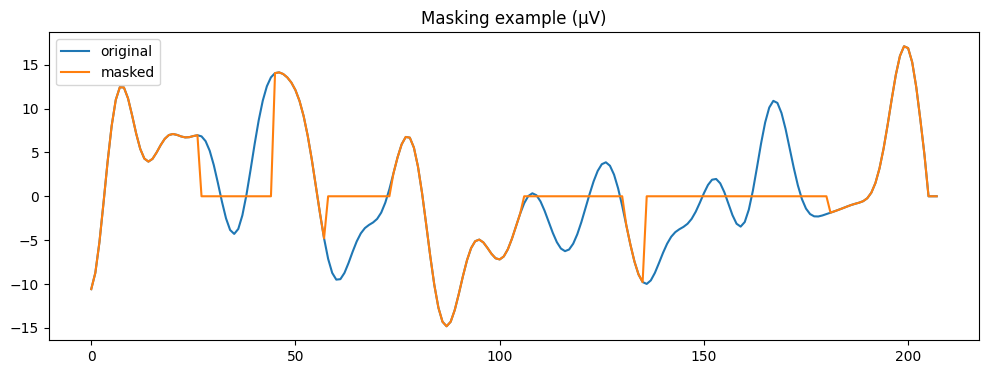

In [20]:
# визуализация masking
import matplotlib.pyplot as plt

ch = 0

plt.figure(figsize=(12,4))
plt.plot(x[ch]*1e6, label="original")
plt.plot(x_masked[ch]*1e6, label="masked")
plt.legend()
plt.title("Masking example (µV)")
plt.savefig("Masking_example.png", dpi=300, bbox_inches="tight")
plt.savefig("Masking_example.pdf", bbox_inches="tight")
plt.show()

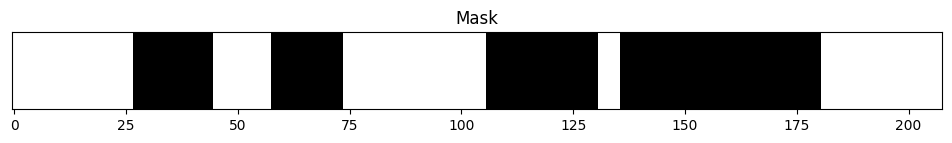

In [21]:
# визуализация mask
plt.figure(figsize=(12,1))
plt.imshow(mask[None,:], aspect="auto", cmap="gray_r")
plt.title("Mask")
plt.yticks([])
plt.show()

In [43]:
import torch


def batch_time_block_mask(x, mask_ratio=0.5, block_size=16, generator=None):
    """
    Apply contiguous time-block masking to a batch of EEG epochs.

    Parameters
    ----------
    x : torch.Tensor
        Input tensor of shape (B, C, L).
    mask_ratio : float
        Approximate fraction of time points to mask.
    block_size : int
        Length of each contiguous masked block.
    generator : torch.Generator or None
        Random generator for reproducible masking. If None, uses default RNG.

    Returns
    -------
    x_masked : torch.Tensor
        Masked input of shape (B, C, L).
    mask : torch.Tensor
        Binary mask of shape (B, L), where 1 = masked.
    """
    assert x.ndim == 3, f"Expected x with shape (B, C, L), got {x.shape}"

    B, C, L = x.shape
    device = x.device

    if block_size > L:
        raise ValueError(f"block_size={block_size} cannot be greater than sequence length L={L}")

    n_mask_target = int(L * mask_ratio)
    mask = torch.zeros(B, L, device=device, dtype=x.dtype)

    for b in range(B):
        masked = 0
        while masked < n_mask_target:
            start = torch.randint(
                low=0,
                high=L - block_size + 1,
                size=(1,),
                device=device,
                generator=generator,
            ).item()

            end = start + block_size

            newly = 1.0 - mask[b, start:end]
            mask[b, start:end] = 1.0
            masked += int(newly.sum().item())

    x_masked = x * (1.0 - mask.unsqueeze(1))  # (B, C, L)

    return x_masked, mask

## 5. Dataset и DataLoader

In [44]:
import numpy as np
import zarr
import torch
from torch.utils.data import Dataset


class SSLZarrDataset(Dataset):
    def __init__(self, zarr_path, indices, scale_to_uv=True):
        """
        Dataset for SSL pretraining from Zarr array.

        Parameters
        ----------
        zarr_path : str
            Path to Zarr root.
        indices : array-like
            Epoch indices to use in this dataset (e.g. train_idx or val_idx).
        scale_to_uv : bool
            Whether to scale signals from volts to microvolts.
        """
        self.root = zarr.open(zarr_path, mode="r")
        self.X = self.root["X"]
        self.indices = np.asarray(indices, dtype=np.int64)
        self.scale_to_uv = scale_to_uv

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])

        x = self.X[real_idx]                  # (14, 208)
        x = np.asarray(x, dtype=np.float32)

        if self.scale_to_uv:
            x = x * 1e6

        return torch.from_numpy(x)           # (C, L)

In [48]:
train_dataset = SSLZarrDataset(
    zarr_path=zarr_path,
    indices=train_idx,
    scale_to_uv=True,
)

val_dataset = SSLZarrDataset(
    zarr_path=zarr_path,
    indices=val_idx,
    scale_to_uv=True,
)

In [74]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [50]:
# Проверка
x_batch = next(iter(train_loader))
print("Train batch:", x_batch.shape, x_batch.dtype)

x_batch_val = next(iter(val_loader))
print("Val batch  :", x_batch_val.shape, x_batch_val.dtype)

Train batch: torch.Size([64, 14, 208]) torch.float32
Val batch  : torch.Size([64, 14, 208]) torch.float32


In [52]:
x_batch = next(iter(train_loader))
print(x_batch.shape, x_batch.dtype)

torch.Size([64, 14, 208]) torch.float32


## 6. Модель

In [53]:
import torch
import torch.nn as nn

class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool1d(kernel_size=2, stride=2),
            DoubleConv1D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up1D(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)
            mid_channels = in_channels // 2
            self.conv = DoubleConv1D(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv = DoubleConv1D(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: низ, x2: skip
        x1 = self.up(x1)

        # подгоняем длину, если не совпадает
        diff = x2.size(-1) - x1.size(-1)
        if diff > 0:
            x1 = nn.functional.pad(x1, (diff // 2, diff - diff // 2))
        elif diff < 0:
            x2 = nn.functional.pad(x2, (-diff // 2, -diff - (-diff // 2)))

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet1D_Light(nn.Module):
    """
    U-Net 1D с 4 уровнями даунсемплинга, вдохновлён Hong et al., 2025.
    Каналы: 32 → 64 → 128 → 256, bottleneck 512.
    """
    def __init__(self, n_channels, n_classes, base_ch=32, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ch1 = base_ch
        ch2 = base_ch * 2
        ch3 = base_ch * 4
        ch4 = base_ch * 8
        bottleneck_ch = base_ch * 16  # 512 при base_ch=32

        # encoder
        self.inc = DoubleConv1D(n_channels, ch1)
        self.down1 = Down1D(ch1, ch2)
        self.down2 = Down1D(ch2, ch3)
        self.down3 = Down1D(ch3, ch4)
        self.down4 = Down1D(ch4, bottleneck_ch)

        # decoder
        self.up1 = Up1D(bottleneck_ch + ch4, ch4, bilinear)
        self.up2 = Up1D(ch4 + ch3, ch3, bilinear)
        self.up3 = Up1D(ch3 + ch2, ch2, bilinear)
        self.up4 = Up1D(ch2 + ch1, ch1, bilinear)
        self.outc = OutConv1D(ch1, n_classes)

    def encode(self, x):
        x1 = self.inc(x)     # (N, ch1, L)
        x2 = self.down1(x1)  # (N, ch2, L/2)
        x3 = self.down2(x2)  # (N, ch3, L/4)
        x4 = self.down3(x3)  # (N, ch4, L/8)
        x5 = self.down4(x4)  # (N, bottleneck_ch, L/16)
        return x1, x2, x3, x4, x5

    def decode(self, x1, x2, x3, x4, x5):
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encode(x)
        logits = self.decode(x1, x2, x3, x4, x5)
        return logits, x5  # x5 — bottleneck

In [79]:

device = "cuda"

model = UNet1D_Light(n_channels=14, n_classes=14)
model = model.to(device)

print("Model ready")

Model ready


## 6. Loss

In [57]:
# masked loss функция
import torch

def masked_l1_loss(recon, target, mask, eps=1e-8):
    """
    recon:  (B, C, L)
    target: (B, C, L)
    mask:   (B, L), where 1 = masked
    """
    mask = mask.unsqueeze(1).to(recon.dtype)   # (B, 1, L)

    loss = torch.abs(recon - target) * mask    # broadcasting to (B, C, L)

    denom = mask.sum() * recon.shape[1]        # masked positions × channels
    return loss.sum() / (denom + eps)
    

In [58]:
# sanity check
x = next(iter(train_loader)).to(device)              # (B, C, L)
x_masked, mask = batch_time_block_mask(x, mask_ratio=0.5, block_size=16)

with torch.no_grad():
    recon, z = model(x_masked)

loss = masked_l1_loss(recon, x, mask)

print("x       :", x.shape)
print("x_masked:", x_masked.shape)
print("mask    :", mask.shape)
print("recon   :", recon.shape)
print("z       :", z.shape)
print("loss    :", float(loss))

x       : torch.Size([64, 14, 208])
x_masked: torch.Size([64, 14, 208])
mask    : torch.Size([64, 208])
recon   : torch.Size([64, 14, 208])
z       : torch.Size([64, 512, 13])
loss    : 18.548309326171875


## 8. Optimizer + Scheduler

In [80]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [81]:
# scheduler
max_epochs = 200

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max_epochs
)

## 9. Training loop

In [82]:
scaler = torch.amp.GradScaler("cuda")

In [83]:
# Train / Validation functions
import os
import json
import torch
from tqdm import tqdm


def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    scaler,
    mask_ratio=0.5,
    block_size=16,
):
    model.train()

    total_loss = 0.0
    n_batches = 0

    for x in tqdm(loader, desc="Train", leave=False):
        x = x.to(device, non_blocking=True)

        # random masking for train
        x_masked, mask = batch_time_block_mask(
            x,
            mask_ratio=mask_ratio,
            block_size=block_size,
            generator=None,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            recon, _ = model(x_masked)
            loss = masked_l1_loss(recon, x, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device,
    mask_ratio=0.5,
    block_size=16,
    val_seed=2026,
):
    model.eval()

    total_loss = 0.0
    n_batches = 0

    # fixed generator for reproducible validation masking
    val_generator = torch.Generator(device=device)
    val_generator.manual_seed(val_seed)

    for x in tqdm(loader, desc="Val", leave=False):
        x = x.to(device, non_blocking=True)

        x_masked, mask = batch_time_block_mask(
            x,
            mask_ratio=mask_ratio,
            block_size=block_size,
            generator=val_generator,
        )

        with torch.amp.autocast("cuda"):
            recon, _ = model(x_masked)
            loss = masked_l1_loss(recon, x, mask)

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)

In [71]:
# Save helpers
def save_encoder_checkpoint(model, save_path):
    """
    Saves only encoder weights for downstream use.
    """
    encoder_state = {
        "inc": model.inc.state_dict(),
        "down1": model.down1.state_dict(),
        "down2": model.down2.state_dict(),
        "down3": model.down3.state_dict(),
        "down4": model.down4.state_dict(),
    }
    torch.save(encoder_state, save_path)


def save_full_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_loss, save_path):
    """
    Saves full training state for resume.
    """
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_loss": best_val_loss,
        },
        save_path,
    )

### Проверки перед запуском полного цикла обучения

In [85]:
import time

t0 = time.time()
x = next(iter(train_loader))
t1 = time.time()

print("Time to load one batch:", t1 - t0, "sec")
print(x.shape, x.dtype)

Time to load one batch: 0.6121649742126465 sec
torch.Size([64, 14, 208]) torch.float32


In [84]:
# Проверка одного полного шага train + val
# single train step
train_loss = train_one_epoch(
    model=model,
    loader=train_loader,
    optimizer=optimizer,
    device=device,
    scaler=scaler,
)

print("Train loss:", train_loss)


# single validation step
val_loss = validate_one_epoch(
    model=model,
    loader=val_loader,
    device=device,
)

print("Val loss:", val_loss)

KeyboardInterrupt: 

In [73]:
# Проверка scheduler
print("LR before step:", optimizer.param_groups[0]["lr"])

scheduler.step()

print("LR after step:", optimizer.param_groups[0]["lr"])

LR before step: 0.0003
LR after step: 0.0002999814948722491


In [75]:
# Проверка сохранения encoder
test_path = "/kaggle/working/test_encoder.pt"

save_encoder_checkpoint(model, test_path)

print("Saved:", test_path)

Saved: /kaggle/working/test_encoder.pt


In [76]:
import os
print(os.path.exists(test_path))

True


In [ ]:
# Мини-тест masking на validation
x = next(iter(val_loader)).to(device)

g1 = torch.Generator(device=device)
g1.manual_seed(2026)

g2 = torch.Generator(device=device)
g2.manual_seed(2026)

xm1, m1 = batch_time_block_mask(x, generator=g1)
xm2, m2 = batch_time_block_mask(x, generator=g2)

print("Mask identical:", torch.allclose(m1, m2))

### Полный цикл обучения

In [65]:
# Main training loop with early stopping
# =========================
# Training config
# =========================
max_epochs = 200
patience = 15
min_delta = 1e-4

mask_ratio = 0.5
block_size = 16
checkpoint_every = 10

save_dir = "/kaggle/working/ssl_checkpoints"
os.makedirs(save_dir, exist_ok=True)

history = {
    "train_loss": [],
    "val_loss": [],
}

best_val_loss = float("inf")
epochs_without_improvement = 0


for epoch in range(1, max_epochs + 1):
    print(f"\nEpoch [{epoch}/{max_epochs}]")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        scaler=scaler,
        mask_ratio=mask_ratio,
        block_size=block_size,
    )

    val_loss = validate_one_epoch(
        model=model,
        loader=val_loader,
        device=device,
        mask_ratio=mask_ratio,
        block_size=block_size,
        val_seed=2026,   # fixed seed for stable validation masking
    )

    scheduler.step()

    history["train_loss"].append(float(train_loss))
    history["val_loss"].append(float(val_loss))

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"train_loss={train_loss:.6f} | "
        f"val_loss={val_loss:.6f} | "
        f"lr={current_lr:.6e}"
    )

    # -------------------------
    # Save best encoder
    # -------------------------
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        best_encoder_path = os.path.join(save_dir, "encoder_best.pt")
        save_encoder_checkpoint(model, best_encoder_path)

        best_full_path = os.path.join(save_dir, "checkpoint_best_full.pt")
        save_full_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            best_val_loss=best_val_loss,
            save_path=best_full_path,
        )

        print(f"New best val loss: {best_val_loss:.6f} -> saved best encoder")

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s)")

    # -------------------------
    # Periodic encoder checkpoints
    # -------------------------
    if epoch % checkpoint_every == 0:
        periodic_path = os.path.join(save_dir, f"encoder_epoch_{epoch:03d}.pt")
        save_encoder_checkpoint(model, periodic_path)
        print(f"Saved periodic encoder checkpoint: {periodic_path}")

    # -------------------------
    # Save last full checkpoint every epoch
    # -------------------------
    last_full_path = os.path.join(save_dir, "checkpoint_last_full.pt")
    save_full_checkpoint(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        epoch=epoch,
        best_val_loss=best_val_loss,
        save_path=last_full_path,
    )

    # -------------------------
    # Early stopping
    # -------------------------
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break


Epoch [1/200]


KeyboardInterrupt: 

In [ ]:
# Save last encoder + history
last_encoder_path = os.path.join(save_dir, "encoder_last.pt")
save_encoder_checkpoint(model, last_encoder_path)
print(f"Saved last encoder: {last_encoder_path}")

In [ ]:
history_path = os.path.join(save_dir, "loss_history.json")
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)

print(f"Saved history: {history_path}")

In [ ]:
# Небольшой график loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Masked L1 Loss")
plt.title("SSL pretraining loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(save_dir, "ssl_loss_curve.png"), dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "ssl_loss_curve.pdf"), bbox_inches="tight")
plt.show()

## 10. Быстрая визуальная проверка реконструкций

In [ ]:
print("orig min/max:", orig.min(), orig.max())
print("recon min/max:", reconstructed.min(), reconstructed.max())

In [ ]:
model.eval()

x = next(iter(loader)).to(device)
x_masked, mask = batch_time_block_mask(x)

with torch.no_grad():
    recon, z = model(x_masked)

# возьмём первый пример и первый канал
orig = x[0, 0].cpu().numpy()
masked = x_masked[0, 0].cpu().numpy()
reconstructed = recon[0, 0].cpu().numpy()
mask_np = mask[0].cpu().numpy()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(orig * 1e6, label="Original")
plt.plot(masked * 1e6, label="Masked")
plt.plot(reconstructed * 1e6, label="Reconstructed")
plt.legend()
plt.title("SSL Reconstruction Check (µV)")
plt.show()

In [ ]:
print("Bottleneck shape:", z.shape)

## 11. Сохранение артефактов

In [ ]:
# Сохранить энкодер отдельно
torch.save(
    {
        "inc": model.inc.state_dict(),
        "down1": model.down1.state_dict(),
        "down2": model.down2.state_dict(),
        "down3": model.down3.state_dict(),
        "down4": model.down4.state_dict(),
    },
    "/kaggle/working/encoder_ssl_02.pt"
)

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/unet_ssl_final_v2.pt")